In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings


In [2]:
df = pd.read_csv('Data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Std             1552 non-null   str    
 1   ID              1552 non-null   str    
 2   Material        1552 non-null   str    
 3   Heat treatment  802 non-null    str    
 4   Su              1552 non-null   int64  
 5   Sy              1552 non-null   str    
 6   A5              1346 non-null   float64
 7   Bhn             463 non-null    float64
 8   E               1552 non-null   int64  
 9   G               1552 non-null   int64  
 10  mu              1552 non-null   float64
 11  Ro              1552 non-null   int64  
 12  pH              193 non-null    float64
 13  Desc            981 non-null    str    
 14  HV              165 non-null    float64
dtypes: float64(5), int64(4), str(6)
memory usage: 299.1 KB


In [3]:
(df.isnull().sum()/len(df))*100


Std                0.000000
ID                 0.000000
Material           0.000000
Heat treatment    48.324742
Su                 0.000000
Sy                 0.000000
A5                13.273196
Bhn               70.167526
E                  0.000000
G                  0.000000
mu                 0.000000
Ro                 0.000000
pH                87.564433
Desc              36.791237
HV                89.368557
dtype: float64

In [4]:
dropper = ['Bhn', 'pH', 'HV','Desc'] 

In [5]:
df.dropna(subset=['Heat treatment'], inplace=True)
df = df.drop(columns=dropper)
df.info()

<class 'pandas.DataFrame'>
Index: 802 entries, 0 to 1513
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Std             802 non-null    str    
 1   ID              802 non-null    str    
 2   Material        802 non-null    str    
 3   Heat treatment  802 non-null    str    
 4   Su              802 non-null    int64  
 5   Sy              802 non-null    str    
 6   A5              705 non-null    float64
 7   E               802 non-null    int64  
 8   G               802 non-null    int64  
 9   mu              802 non-null    float64
 10  Ro              802 non-null    int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 130.6 KB


In [6]:
df.dropna(subset=['Heat treatment'], inplace=True)
df =df.dropna(subset=['Heat treatment'])

In [7]:
df.head()

,Std,ID,Material,Heat treatment,Su,Sy,A5,E,G,mu,Ro
0,ANSI,D8894772B88F495093C43AF905AB6373,Steel SAE 1015,as-rolled,421,314,39.0,207000,79000,0.3,7860
1,ANSI,05982AC66F064F9EBC709E7A4164613A,Steel SAE 1015,normalized,424,324,37.0,207000,79000,0.3,7860
2,ANSI,356D6E63FF9A49A3AB23BF66BAC85DC3,Steel SAE 1015,annealed,386,284,37.0,207000,79000,0.3,7860
3,ANSI,1C758F8714AC4E0D9BD8D8AE1625AECD,Steel SAE 1020,as-rolled,448,331,36.0,207000,79000,0.3,7860
4,ANSI,DCE10036FC1946FC8C9108D598D116AD,Steel SAE 1020,normalized,441,346,35.8,207000,79000,0.3,7860


In [8]:
df.info()
df['Sy'] = pd.to_numeric(df["Sy"],errors='coerce')

<class 'pandas.DataFrame'>
Index: 802 entries, 0 to 1513
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Std             802 non-null    str    
 1   ID              802 non-null    str    
 2   Material        802 non-null    str    
 3   Heat treatment  802 non-null    str    
 4   Su              802 non-null    int64  
 5   Sy              802 non-null    str    
 6   A5              705 non-null    float64
 7   E               802 non-null    int64  
 8   G               802 non-null    int64  
 9   mu              802 non-null    float64
 10  Ro              802 non-null    int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 130.6 KB


In [9]:
df.describe()



,Su,Sy,A5,E,G,mu,Ro
count,802.000000,802.000000,705.000000,802.000000,802.000000,802.000000,802.000000
mean,630.819202,446.684539,16.026099,159251.870324,103849.127182,0.309027,6045.145885
std,394.396080,348.850352,10.361937,63107.176755,171462.457152,0.015660,2521.218412
min,69.000000,28.000000,1.000000,73000.000000,26000.000000,0.290000,1750.000000
25%,310.000000,214.000000,10.000000,73000.000000,26000.000000,0.300000,2700.000000
50%,574.500000,345.500000,14.000000,204000.000000,79000.000000,0.300000,7850.000000
75%,800.000000,556.000000,20.000000,206000.000000,80000.000000,0.330000,7860.000000
max,2220.000000,2048.000000,60.000000,219000.000000,769000.000000,0.330000,8800.000000


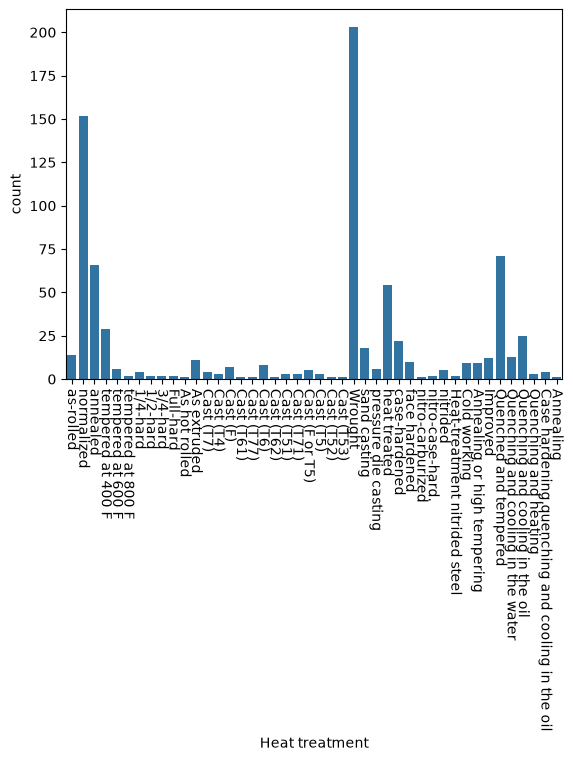

In [10]:
sns.countplot(data=df, x='Heat treatment')
plt.xticks(rotation=270)
plt.show()

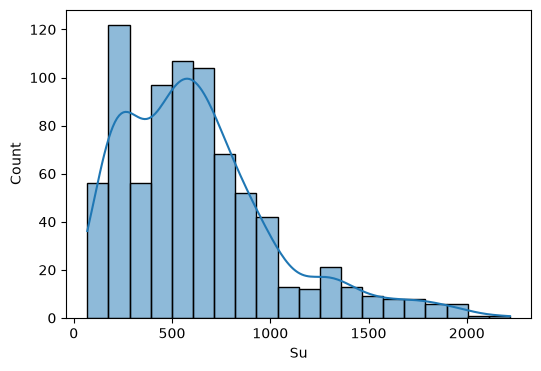

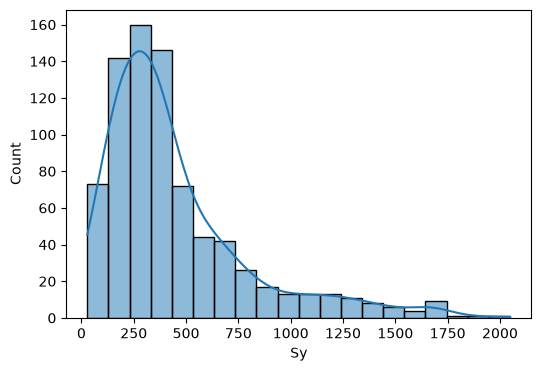

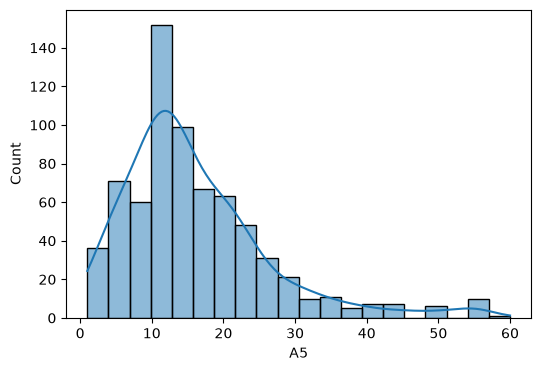

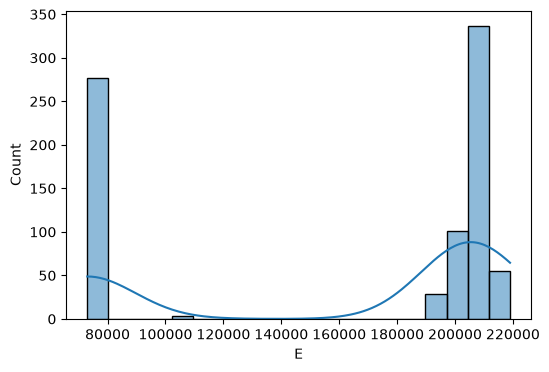

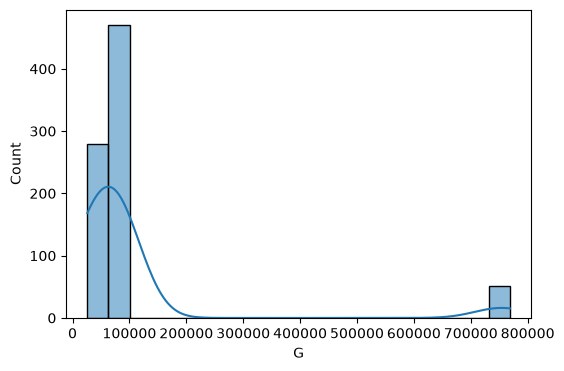

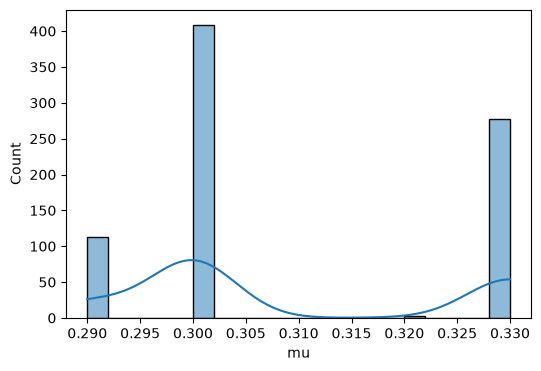

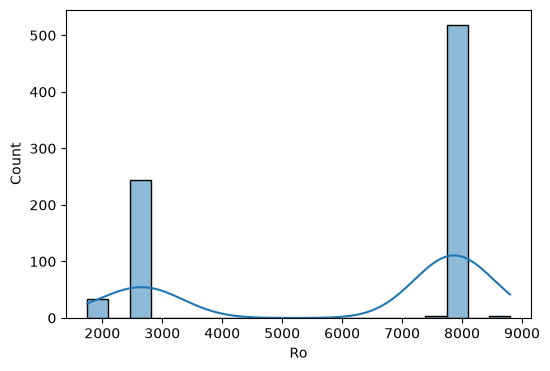

In [11]:
num_col = ['Su','Sy','A5','E','G','mu','Ro']
for col in num_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins =20)

In [12]:
df['Heat treatment'].value_counts()

Heat treatment
Wrought                                            203
normalized                                         152
Quenched and tempered                               71
annealed                                            66
heat treated                                        54
tempered at 400 F                                   29
Quenching and cooling in the oil                    25
case-hardened                                       22
sand casting                                        18
as-rolled                                           14
Quenching and cooling in the water                  13
Improved                                            12
As extruded                                         11
face hardened                                       10
Cold working                                         9
Annealing or high tempering                          9
Cast (T6)                                            8
Cast (F)                                          

In [13]:
top_5_treatment = df['Heat treatment'].value_counts().nlargest(5).index

df =df[df['Heat treatment'].isin(top_5_treatment)]

df.isnull().sum()

Std                0
ID                 0
Material           0
Heat treatment     0
Su                 0
Sy                 0
A5                28
E                  0
G                  0
mu                 0
Ro                 0
dtype: int64

In [14]:
df['A5'] = df['A5'].fillna(df['A5'].median())

In [15]:
#ttS(TRAIN TEST SPLIT)

X = df.drop(columns=['Heat treatment','ID','Material','E','G','mu','Ro'])
X= pd.get_dummies(X,columns=['Std'],drop_first=True)
y= df['Heat treatment']

X.head()

,Su,Sy,A5,Std_BS,Std_CSN,Std_DIN,Std_GOST,Std_ISO,Std_JIS,Std_NF
1,424,324,37.0,False,False,False,False,False,False,False
2,386,284,37.0,False,False,False,False,False,False,False
4,441,346,35.8,False,False,False,False,False,False,False
5,395,295,36.5,False,False,False,False,False,False,False
7,483,359,34.0,False,False,False,False,False,False,False


<Axes: xlabel='Std', ylabel='count'>

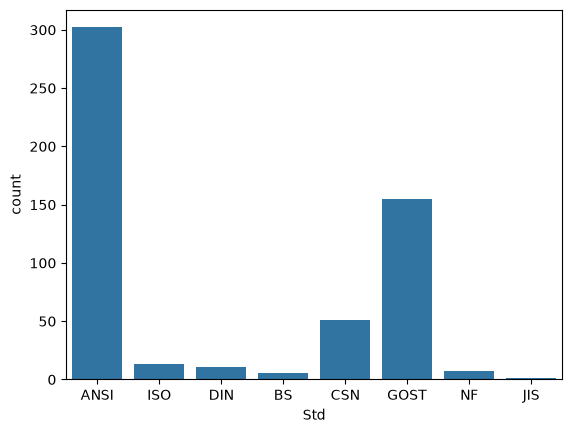

In [16]:
sns.countplot(x = df['Std'])

In [17]:
df['Material'].nunique()

436

In [18]:

df['ID'].nunique()

546

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report

In [20]:
#LOGISTIC REGRESSION MODEL
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler =StandardScaler()
X_train_scaled =scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model_logReg = LogisticRegression(max_iter=1000)
model_logReg.fit(X_train_scaled, y_train)

y_pred = model_logReg.predict(X_test_scaled)



In [21]:
#LOGISTIC REGRESSION RESULTS
print(f' Overall Accuracy: {accuracy_score(y_test,y_pred)*100:.2f}%')
print(classification_report(y_test,y_pred))

 Overall Accuracy: 88.18%
                       precision    recall  f1-score   support

Quenched and tempered       0.73      0.57      0.64        14
              Wrought       1.00      1.00      1.00        41
             annealed       0.80      0.92      0.86        13
         heat treated       1.00      0.91      0.95        11
           normalized       0.79      0.84      0.81        31

             accuracy                           0.88       110
            macro avg       0.86      0.85      0.85       110
         weighted avg       0.88      0.88      0.88       110



In [22]:
#KNN MODEL

from sklearn.neighbors import KNeighborsClassifier

model_knn =KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled,y_train)

y_pred_knn= model_knn.predict(X_test_scaled)

In [23]:
#KNN RESULTS
print(f'Overall accuracy: {accuracy_score(y_test,y_pred_knn)*100:.2f}')
print(classification_report(y_test,y_pred_knn))

Overall accuracy: 89.09
                       precision    recall  f1-score   support

Quenched and tempered       0.71      0.86      0.77        14
              Wrought       1.00      1.00      1.00        41
             annealed       0.80      0.92      0.86        13
         heat treated       0.90      0.82      0.86        11
           normalized       0.89      0.77      0.83        31

             accuracy                           0.89       110
            macro avg       0.86      0.87      0.86       110
         weighted avg       0.90      0.89      0.89       110



In [24]:
#NAVE_BAyes model 

from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()
model_nb.fit(X_train_scaled,y_train)
y_pred_nb = model_nb.predict(X_test_scaled)

In [25]:
#Naive Bayes PRediction
print(f'Overall accuracy:{accuracy_score(y_test,y_pred_nb)*100:.2f}%')
print()
print(classification_report(y_test,y_pred_nb))

Overall accuracy:72.73%

                       precision    recall  f1-score   support

Quenched and tempered       0.44      1.00      0.61        14
              Wrought       1.00      0.90      0.95        41
             annealed       0.54      1.00      0.70        13
         heat treated       1.00      0.73      0.84        11
           normalized       0.89      0.26      0.40        31

             accuracy                           0.73       110
            macro avg       0.77      0.78      0.70       110
         weighted avg       0.84      0.73      0.71       110



In [26]:
#Deceison Tree Model

from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(criterion='entropy', random_state=42)

model_dt.fit(X_train_scaled,y_train)
y_pred_dt = model_dt.predict(X_test_scaled)

In [27]:
#DT Prediction
print(f'Overall accuracy:{accuracy_score(y_test,y_pred_dt)*100:.2f}%')
print()
print(classification_report(y_test,y_pred_dt))

Overall accuracy:81.82%

                       precision    recall  f1-score   support

Quenched and tempered       0.73      0.79      0.76        14
              Wrought       1.00      1.00      1.00        41
             annealed       0.62      0.62      0.62        13
         heat treated       0.77      0.91      0.83        11
           normalized       0.71      0.65      0.68        31

             accuracy                           0.82       110
            macro avg       0.77      0.79      0.78       110
         weighted avg       0.82      0.82      0.82       110



In [28]:
#SVM MODELabs
from sklearn.svm import SVC
model_svm = SVC(kernel='rbf', random_state=42)

model_svm.fit(X_train_scaled, y_train)
y_pred_svm = model_svm.predict(X_test_scaled)



In [29]:
#sSVm prediction

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_svm) * 100:.2f}%\n")
print(classification_report(y_test, y_pred_svm))

Overall Accuracy: 89.09%

                       precision    recall  f1-score   support

Quenched and tempered       0.73      0.57      0.64        14
              Wrought       1.00      1.00      1.00        41
             annealed       0.81      1.00      0.90        13
         heat treated       1.00      0.91      0.95        11
           normalized       0.81      0.84      0.83        31

             accuracy                           0.89       110
            macro avg       0.87      0.86      0.86       110
         weighted avg       0.89      0.89      0.89       110

